In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from wave_optics_propagation.visualization import plot_wavefunction

### Initial parameters


In [2]:
# beam parameters
vacuum_wavelength = 1e-6
beam_FWHM = 5e-3

# lens parameters
focal_length = 200e-3
# lens_diameter = 25e-3
lens_diameter = 50e-3
refractive_index = 1.5

# free space propagation parameters
propagation_after_lens = 1.5 * focal_length

# simulation parameters
transverse_length = 100e-3  # transverse simulation window
num_of_steps_after_lens = 10
lens_slices = 100
num_qubits = 8
max_delta = 0.01

### Constants


In [3]:
c = constants.c
# hbar = constants.hbar

### Derived parameters


In [4]:
# geometry
radius_of_curvature = focal_length * (refractive_index - 1)
lens_radius = lens_diameter / 2
lens_thickness = radius_of_curvature - np.sqrt(radius_of_curvature**2 - lens_radius**2)


k_0 = 2 * constants.pi / vacuum_wavelength
reduced_wavelength = vacuum_wavelength / refractive_index

dimension = 2**num_qubits
delta_x = transverse_length / dimension

gaussian_mean = transverse_length / 2
gaussian_beam_waist = beam_FWHM / np.sqrt(2 * np.log(2))
# gaussian_sigma = gaussian_beam_waist / np.sqrt(2)

# vacuum_rayleigh_length = (np.pi * gaussian_beam_waist**2) / vacuum_wavelength

lens_slice_thickness = lens_thickness / lens_slices
step_size_after_lens = propagation_after_lens / num_of_steps_after_lens

In [5]:
from qiskit_signals.quantum_axis import (
    AngularWavenumberAxis,
    EncodingType,
    PositionAxis,
)

x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)
k_axis = AngularWavenumberAxis.from_position_axis(x_axis)

In [6]:
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)

z = 400
R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
    gaussian_beam_waist,
    z,
    focal_length,
    vacuum_wavelength,
    refractive_index,
)
R_f, w_f = free_space_propagated_gaussian_wavefront(
    gaussian_beam_waist, z, vacuum_wavelength, 1
)
original_gaussian = gaussian_signal(x_axis, gaussian_beam_waist, gaussian_mean)
signal_no_lens = gaussian_signal(x_axis, w_f, gaussian_mean)
signal_with_lens = gaussian_signal(x_axis, w_z, gaussian_mean)

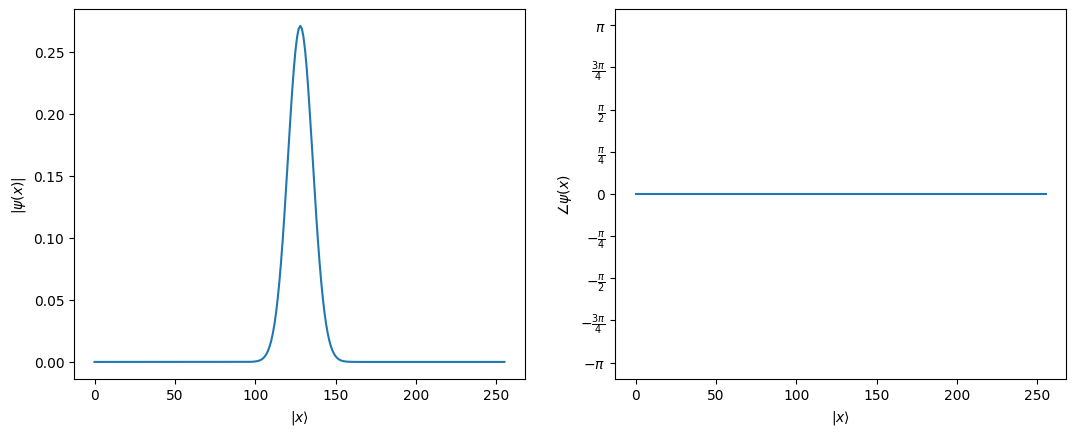

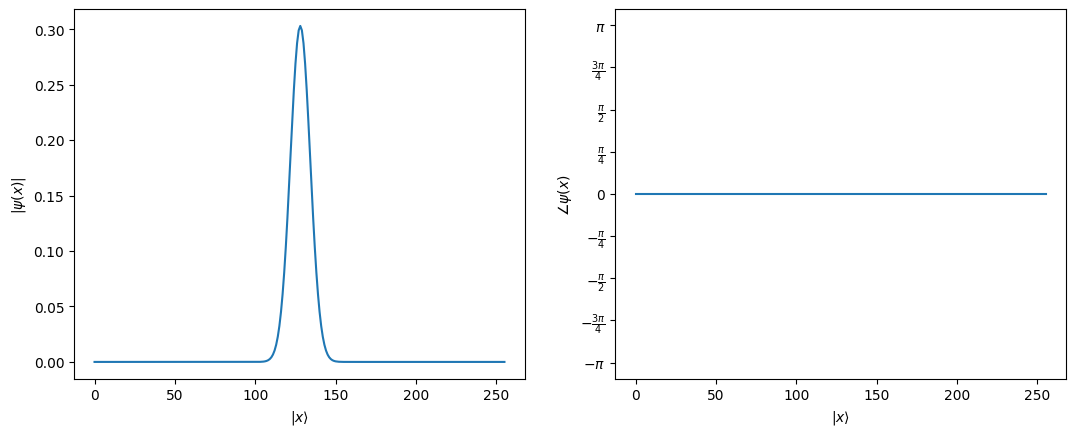

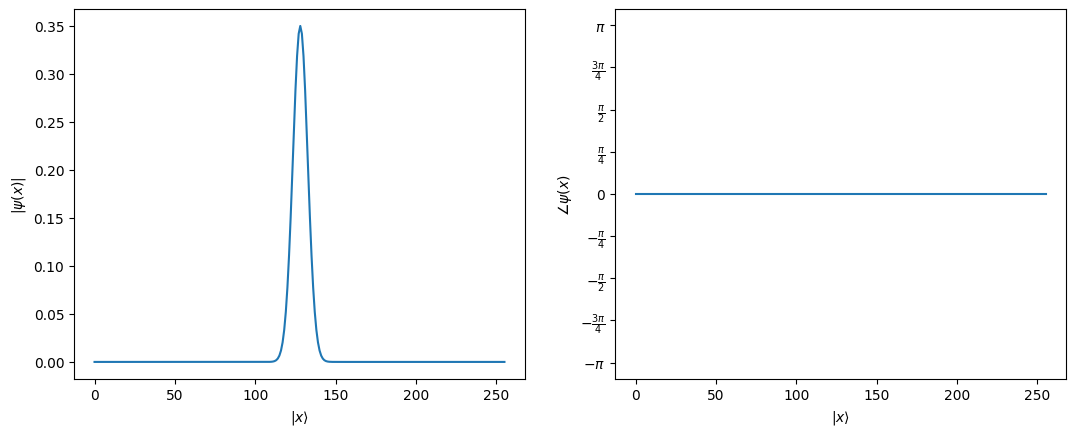

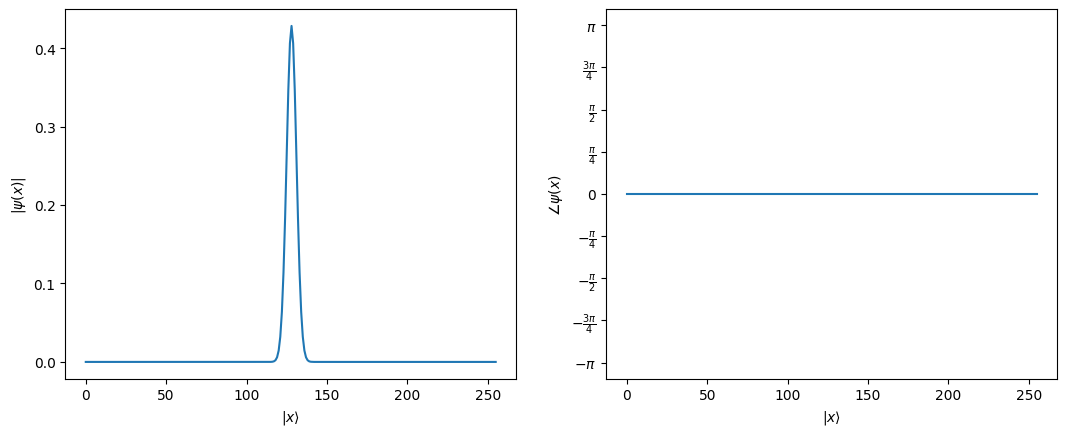

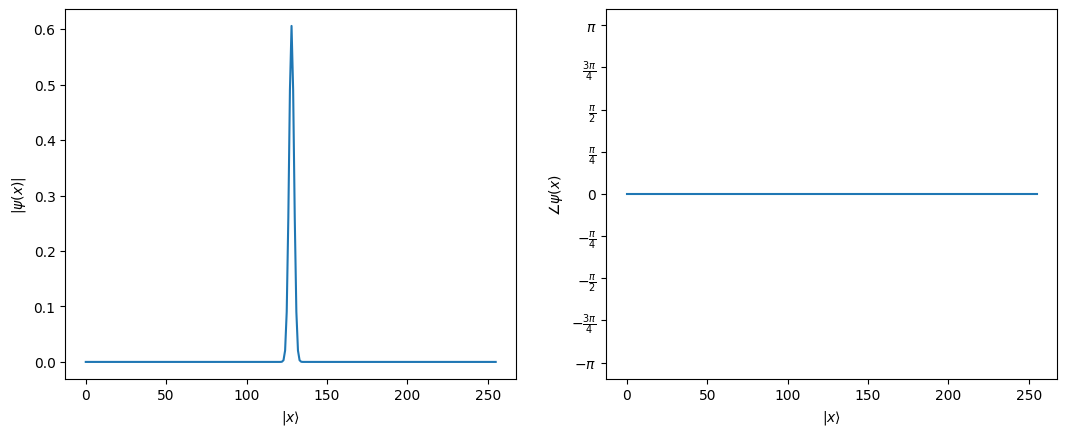

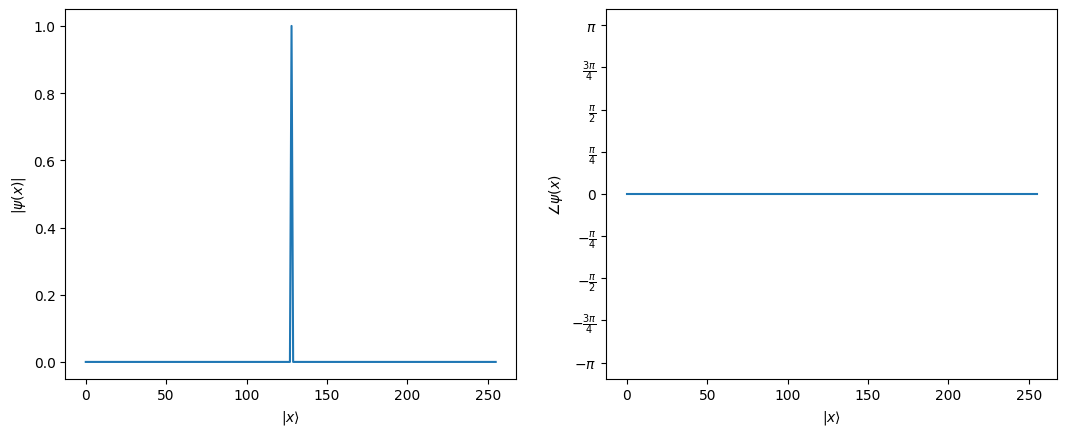

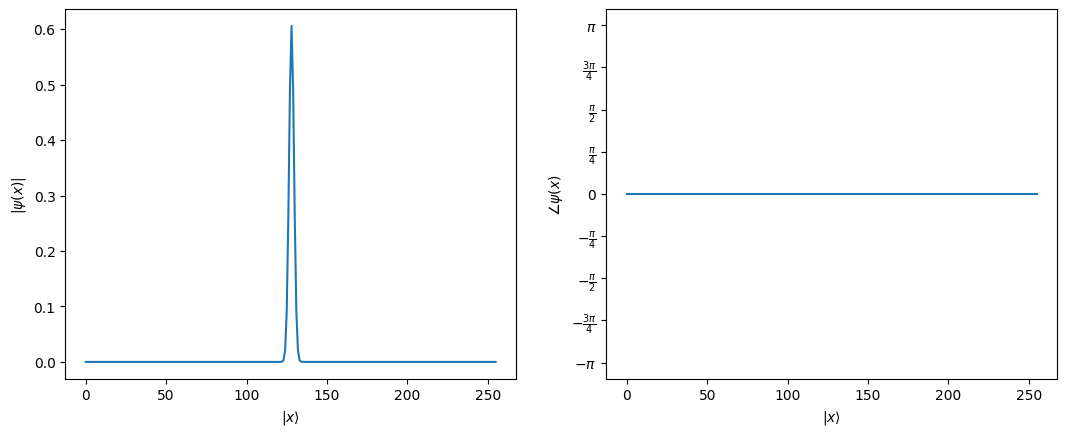

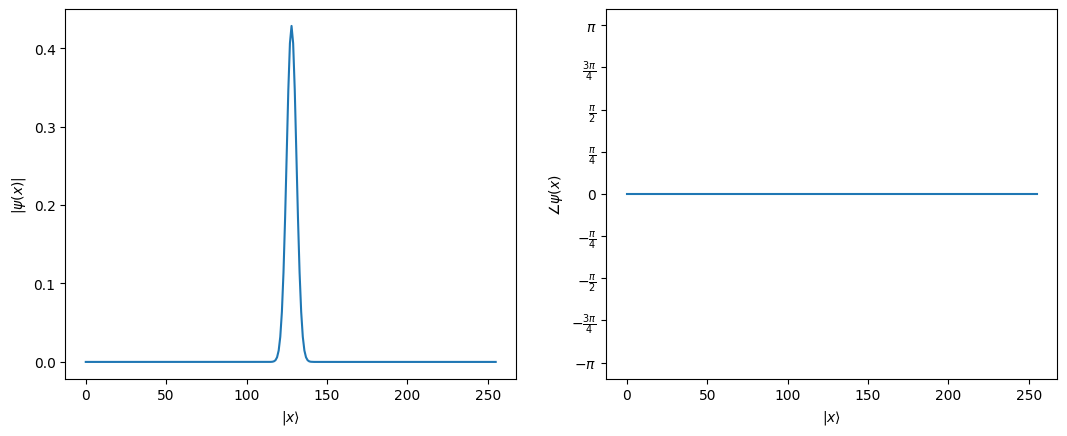

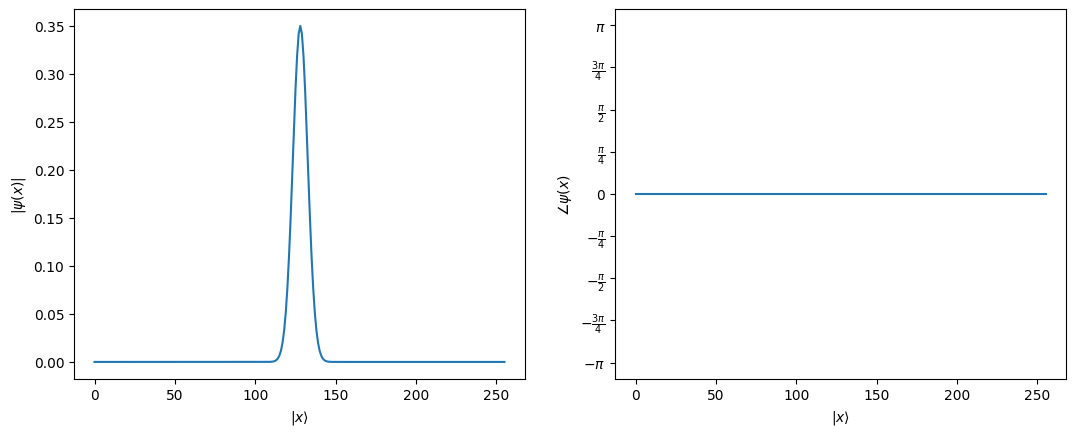

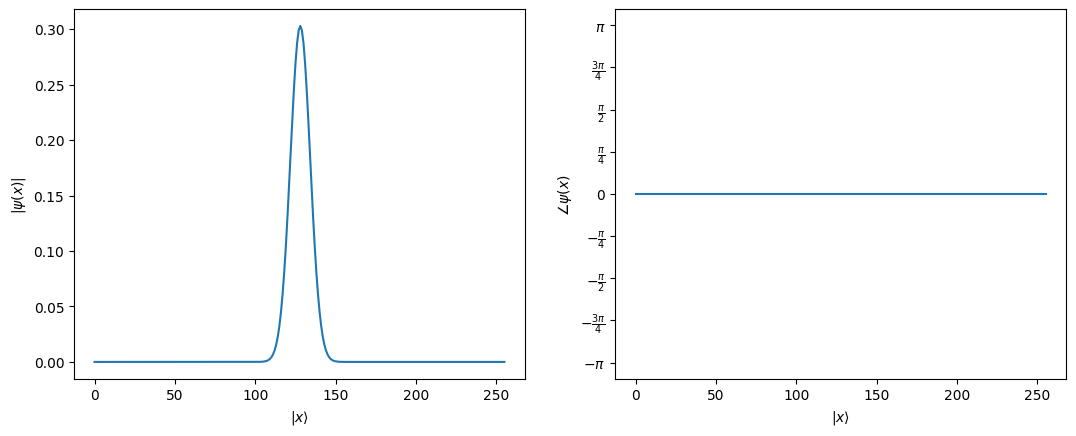

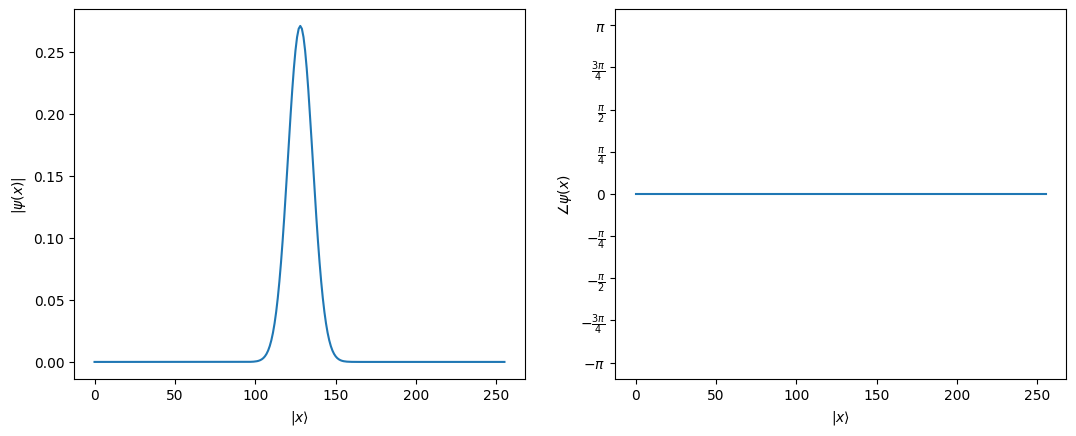

In [7]:
zs = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]) * focal_length
for z in zs:
    R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
        gaussian_beam_waist,
        z,
        focal_length,
        vacuum_wavelength,
        1,
    )
    signal_with_lens = gaussian_signal(x_axis, w_z, gaussian_mean)
    plot_wavefunction(signal_with_lens.data)